In [10]:
# VectorDB에 Image 저장 후 검색 - 이미지로 이미지 검색
!pip install huggingface_hub

In [11]:
from huggingface_hub import list_models
models = list_models(search='clip', limit=20)
for m in models:
    print(m.modelId)

openai/clip-vit-base-patch32
openai/clip-vit-large-patch14
OFA-Sys/chinese-clip-vit-base-patch16
jinaai/jina-clip-v2
openai/clip-vit-base-patch16
sentence-transformers/clip-ViT-L-14
openai/clip-vit-large-patch14-336
codemichaeld/sdxl_clip_g_fp8
molbal/qwen-clip-resampler-adapter
yashm/clip-insect-sex
Galuh/clip-indonesian
Lunran/clip-roberta-base
M-CLIP/M-BERT-Base-69
M-CLIP/M-BERT-Base-ViT-B
M-CLIP/M-BERT-Distil-40
M-CLIP/Swedish-2M
M-CLIP/Swedish-500k
SajjadAyoubi/clip-fa-text
SajjadAyoubi/clip-fa-vision
SaulLu/clip-vit-base-patch32


In [12]:
# clip model로 Image Embedding
!pip install chromadb sentence-transformers torch pillow transformers
!pip install koreanize_matplotlib

In [51]:
import os
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"
import torch
import numpy as np
import matplotlib as plt
import koreanize_matplotlib
from chromadb import PersistentClient
from transformers import CLIPProcessor, CLIPModel
from numpy.linalg import norm
from PIL import Image
from google.colab import files
import matplotlib.pyplot as plt

# image uplode
uploadede = files.upload()

Saving apple.jpg to apple (2).jpg


In [23]:
# CLIP model 준비 작업
model_name = 'openai/clip-vit-base-patch32'     # Hugging Face에 등록된 CLIP 기본 모델
processor = CLIPProcessor.from_pretrained(model_name)   # 데이터를 CLIP 입력 형식으로 전처리
model = CLIPModel.from_pretrained(model_name)   # 데이터를 밀집 벡터로 변환

device = 'cuda' if torch.cuda.is_available() else 'cpu'
model.to(device)    # 모델을 선택한 장치로 이동함
model.eval()    # 학습용 모델이 아니라 추론용으로 사용 - gpu로 쓸지 cpu로 쓸지

print('모델 이름 : ', model_name)
print('사용 장치 : ', device)
print('모델 타입 : ', type(model))

Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

모델 이름 :  openai/clip-vit-base-patch32
사용 장치 :  cuda
모델 타입 :  <class 'transformers.models.clip.modeling_clip.CLIPModel'>


In [27]:
# Image를 CLIP vector로 변환 - 이미지 처리할 때 보통 다 비슷하게 진행됨.
def image_to_vector(img_path):
    image = Image.open(img_path).convert('RGB')

    inputs = processor(         # CLIP processor를 통해 Image를 CLIP model 입력 형식으로 변환
        images=image,           # 전처리 대상 이미지 지정
        return_tensors='pt'     # 결과를 PyTorch 텐서 형식으로 반환
    )

    pixels_values = inputs['pixel_values'].to(device)    # 모델 입력에서 이미지 Tensor를 모델과 같은 장치로 이동

    # 자동 미분 엔진(Autograd)을 비활성화하여 기울기(Gradient) 계산을 멈추는 컨텍스트 관리자(Context Manager)를 사용해야한다.
    with torch.no_grad(): # 역전파를 끄고(기울기 계산 X) 추론만 하겠다는 의미

    # model.vision_model : 이미지를 보고 (두가지)정보를 만듦
      # 1. vision_outputs.last_hidden_state : 이미지를 패치 단위로 나눠줌. 비전 인코더(Vision Encoder)를 통과한 이미지 특징(Visual Features)의 마지막 레이어 출력 텐서
      # 2. vision_outputs.pooler_output : 이미지 전체를 대표하는 하나의 벡터. 비전 모델(예: Vision Transformer)이 처리한 이미지의 전체적인 특징을 대표하는 압축된 임베딩 벡터
      vision_outputs = model.vision_model( # CLIP 이미지 인코더로 이미지 특징을 추출
          pixel_values=pixels_values
      )
      pooled_output = vision_outputs.pooler_output  # 이미지 전체를 대표하는 벡터 꺼내기
      image_features = model.visual_projection(     # 이미지벡터를 CLIP 공통 임베딩 공간으로 변환
          pooled_output
      )

      # 정규화
      image_features = image_features / image_features.norm( # norm:벡터를 보고 크기 추출 -> 벡터 크기를 1로 정규화
          p=2,            # L2 norm을 사용
          dim = -1,       # 마지막 차원을 기준으로 벡터크기 계산
          keepdim = True # 마지막 차원 유지
      )

      vec = image_features.squeeze(0).cpu().numpy() # 차원 축소 : 배치차원을 제거하고 cpu로 이동 후 numpy배열로 반환
      print(f"\n{img_path} -> 이미지 벡터 크기 : {vec.shape}")
      print(f"{img_path} -> 벡터 앞 10개 : {vec[:10]}")
      return vec.tolist() # 이렇게 형태를 변형해줘야 chromadb에 저장가능한 벡터를 반환함.

In [29]:
# 텍스트를 CLIP벡터로 변환하는 함수 생성
def text_to_vector(text):

  inputs = processor(           # CLIP processor를 통해 Text를 CLIP model 입력 형식으로 변환
        text = text,            # 전처리 대상 text 지정
        return_tensors='pt',    # 결과를 PyTorch 텐서 형식으로 반환
        padding = True          # 문장 길이를 맞추기 위해 Padding을 True
    )

  input_ids = inputs['input_ids'].to(device)    # 모델 입력에서 텍스트를 Tensor를 모델과 같은 장치로 이동
  attention_mask = inputs['attention_mask'].to(device) # 실제 token과 패딩을 구분하는 마스크

  # 자동 미분 엔진(Autograd)을 비활성화하여 기울기(Gradient) 계산을 멈추는 컨텍스트 관리자(Context Manager)를 사용해야한다.
  with torch.no_grad(): # 역전파를 끄고(기울기 계산 X) 추론만 하겠다는 의미

  # CLIP model은 vision모델과 text모델이 존재
  # text_model : Text를 보고 정보를 만듦
    text_outputs = model.text_model(              # CLIP 텍스트 인코더로 텍스트 특징을 추출
        input_ids = input_ids,                    # 텍스트 토큰 id 전달
        attention_mask = inputs['attention_mask'] # 패딩 위치를 파악하기 위해 텍스트 어텐션 마스크 전달
    )

    pooled_output = text_outputs.pooler_output    # 문장 전체를 대표하는 벡터 꺼내기
    text_features = model.text_projection(        # 텍스트벡터를 CLIP 공통 임베딩 공간으로 변환
        pooled_output                             # text encoder에서 나온 pooled vector를 전달
    )

    # 정규화
    text_features = text_features / text_features.norm( # norm:벡터를 보고 크기 추출 -> 벡터 크기를 1로 정규화
        p=2,            # L2 norm을 사용
        dim = -1,       # 마지막 차원을 기준으로 벡터크기 계산
        keepdim = True # 마지막 차원 유지(나눗셈이 가능하도록)
    )

    vec = text_features.squeeze(0).cpu().numpy() # 차원 축소 : 배치차원을 제거하고 cpu로 이동 후 numpy배열로 반환
    print(f"\n검색어 : {text} -> 텍스트 벡터 크기 : {vec.shape}")
    print(f"검색어 : {text} -> 벡터 앞 10개 : {vec[:10]}")
    return vec.tolist() # 이렇게 형태를 변형해줘야 chromaDB에 저장가능한 벡터를 반환함.


In [32]:
# chromaDB 초기화 하기
client = PersistentClient(path="./chroma_clip")

try:
  client.delete_collection(name="images_clip")
except:
  pass

collection = client.get_or_create_collection(
    name = "images_clip",
    metadata = {"hnsw:space": "cosine"} # 기본은 L2 ,cosine유사도
)

# 업로드한 이미지 목록 준비
images_files = ['apple.jpg','banana.jpg','peach.jpg']
ids = [f'img{i}' for i in range(len(images_files))]
print('ids :', ids)

image_vectors = {} # 계산된 이미지 저장용 dict

# chromaDB에 저장하기
for img_id, img_path in zip(ids, images_files):
  if not os.path.exists(img_path):
    print(f"파일 없음 {img_path}")
    continue

  vec = image_to_vector(img_path) # 이미지를 CLIP 벡터로 변환한 값을 받아옴
  image_vectors[img_path] = vec

  collection.upsert(       # 같은 id가 있으면 수정, 없으면 추가
      embeddings = [vec],   # 이미지 벡터
      documents=[img_path],
      ids = [img_id],       # 이미지 고유 id
      metadatas = [{'filename': img_path}]
  )
recode = collection.get(
    ids = ['img0'],
    include = ['embeddings','documents','metadatas']
)
if len(recode['ids']) > 0:
  print(f'\n벡터 DB에 저장된 내용 확인')
  print(f'id : {recode['ids'][0]}')
  print(f'문서 : {recode['documents'][0]}')
  print(f'기타정보(부분적인 정보) : {recode['metadatas'][0]}')
  print(f'Vector(앞 10개) : {recode['embeddings'][0][:10]}')
else:
  print(f'\n벡터 DB에 저장된 내용 없음')

ids : ['img0', 'img1', 'img2']

apple.jpg -> 이미지 벡터 크기 : (512,)
apple.jpg -> 벡터 앞 10개 : [ 0.02277591  0.05865676  0.01773717 -0.00433802 -0.05915857 -0.01390264
 -0.0191308   0.02885969  0.05427188  0.0124372 ]

banana.jpg -> 이미지 벡터 크기 : (512,)
banana.jpg -> 벡터 앞 10개 : [ 0.04723365  0.03074174 -0.01181086  0.01342827 -0.05694637 -0.01694234
 -0.01892466 -0.02270217  0.09666158  0.0243647 ]

peach.jpg -> 이미지 벡터 크기 : (512,)
peach.jpg -> 벡터 앞 10개 : [-0.02189564  0.0360175  -0.02679123 -0.01859376 -0.03214611  0.027846
 -0.01693901  0.02887001  0.06511102  0.01191666]

벡터 DB에 저장된 내용 확인
id : img0
문서 : apple.jpg
기타정보(부분적인 정보) : {'filename': 'apple.jpg'}
Vector(앞 10개) : [ 0.02277591  0.05865676  0.01773717 -0.00433802 -0.05915857 -0.01390264
 -0.0191308   0.02885969  0.05427188  0.0124372 ]


In [44]:
# 코사인 유사도 계산 함수 (방향유사도 = 코사인유사도 = 내적 / (vectorA의 길이 * vectorB의 길이))
# CLIP이 이 방법을 사용
def cosine_similarity(vec1, vec2):
  vec1 = np.array(vec1)
  vec2 = np.array(vec2)
  return np.dot(vec1, vec2) / (norm(vec1) * norm(vec2))

# 검색결과를 출력하는 함수
def print_search_resultes(title, query_vec, results):
  # 검색 제목 출력
  print(f'\n{title}')
  # Chroma가 계산한 거리랑 cosine함수로 계산한 거리 비교
  for rank, (doc, meta, dist, vec) in enumerate(
      zip(
          results['documents'][0],
          results['metadatas'][0],
          results['distances'][0],
          results['embeddings'][0]
        ),      # enumerate
      start = 1 # rank
  ):
    score = cosine_similarity(query_vec, vec)
    print(f"\n{rank} 위")
    print(f'  - {"파일명"}:{meta["filename"]}')
    print(f'  - {"문서"}:{doc}')
    print(f'  - {"chroma 거리"}:{dist:.4f}')
    print(f'  - {"검색어와의 코사인 유사도"}:{1 - score:.4f}')



# 이미지로 유사 이미지 검색 =================================================
query_image_path = 'watermelon.jpg' # 검색 기준으로 사용할 이미지
if not os.path.exists(query_image_path):
  print('검색 이미지가 없음')
elif collection.count() == 0:
  print('벡터 DB에 검색할 이미지가 없음')
else:
  query_vec = image_to_vector(query_image_path) # 검색 기준으로 사용할 이미지 벡터화 진행
  if query_vec is None:
    query_vec = image_to_vector(query_image_path) # 계산된 이미지 벡터가 있는지 확인하고 없으면 이미지 벡터 만들어주기

  image_results = collection.query(
      query_embeddings = [query_vec],
      n_results = min(3, collection.count()),    # 저장된 이미지 갯수에서 최소 꺼낼 갯수
      include = ['metadatas', 'distances', 'documents', 'embeddings'] # 검색결과에 포함될 변수들
  )

  print_search_resultes(
      title = f'유사 이미지 검색 결과 : {query_image_path}',
      query_vec = query_vec,
      results = image_results
  )


watermelon.jpg -> 이미지 벡터 크기 : (512,)
watermelon.jpg -> 벡터 앞 10개 : [ 0.0054462  -0.01432531  0.00307069 -0.01940369 -0.01783213 -0.00396016
 -0.05956177  0.03747472  0.10388317  0.01586842]

유사 이미지 검색 결과 : watermelon.jpg

1 위
  - 파일명:peach.jpg
  - 문서:peach.jpg
  - chroma 거리:0.2191
  - 검색어와의 코사인 유사도:0.2191

2 위
  - 파일명:apple.jpg
  - 문서:apple.jpg
  - chroma 거리:0.2224
  - 검색어와의 코사인 유사도:0.2224

3 위
  - 파일명:banana.jpg
  - 문서:banana.jpg
  - chroma 거리:0.2979
  - 검색어와의 코사인 유사도:0.2979


In [55]:
# Text로 유사 이미지 검색 =================================================
# query_text = 'a photo of an watermelon' # CLIP은 영어 검색어가 더 안정적이다.
# query_text = 'a photo of a pink fruit'
query_text = 'show me a picture of red fruit'
# query_text = '바나나 사진이 보여'

if collection.count() == 0:
  print('검색 이미지 없음')
else:
  text_vec = text_to_vector(query_text) # 검색 기준으로 사용할 텍스트 벡터화 진행

  text_results = collection.query(
      query_embeddings = [text_vec],
      n_results = min(3, collection.count()),    # 저장된 이미지 갯수에서 최소 꺼낼 갯수
      include = ['metadatas', 'distances', 'documents', 'embeddings'] # 검색결과에 포함될 변수들
  )

  print_search_resultes(
      title = f'텍스트에 대한 유사 이미지 검색 결과 : {query_text}',
      query_vec = text_vec,
      results = text_results
  )


검색어 : show me a picture of red fruit -> 텍스트 벡터 크기 : (512,)
검색어 : show me a picture of red fruit -> 벡터 앞 10개 : [ 0.01464853  0.01884348 -0.00321702 -0.02070577 -0.0528205  -0.01462923
 -0.00991364 -0.05441066  0.0123715  -0.0354776 ]

텍스트에 대한 유사 이미지 검색 결과 : show me a picture of red fruit

1 위
  - 파일명:apple.jpg
  - 문서:apple.jpg
  - chroma 거리:0.6988
  - 검색어와의 코사인 유사도:0.6988

2 위
  - 파일명:peach.jpg
  - 문서:peach.jpg
  - chroma 거리:0.7222
  - 검색어와의 코사인 유사도:0.7222

3 위
  - 파일명:banana.jpg
  - 문서:banana.jpg
  - chroma 거리:0.7529
  - 검색어와의 코사인 유사도:0.7529


count : 3


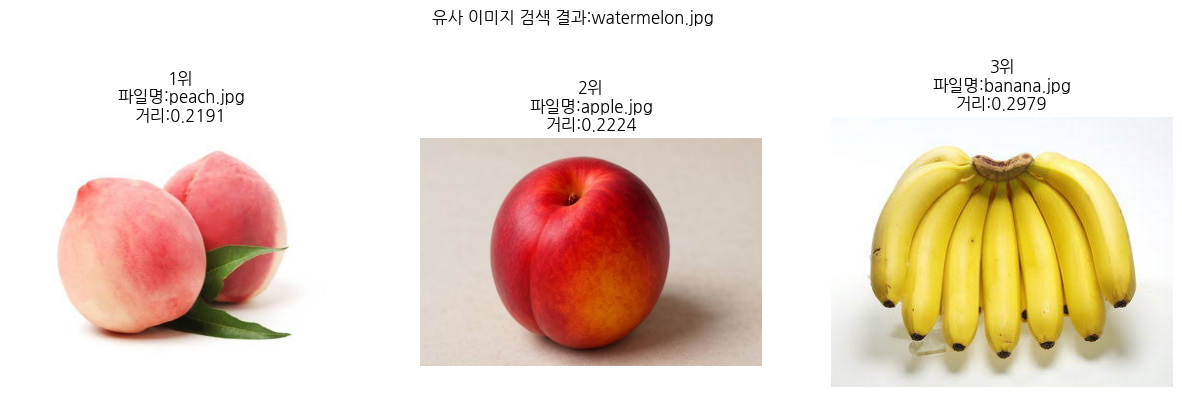

count : 3


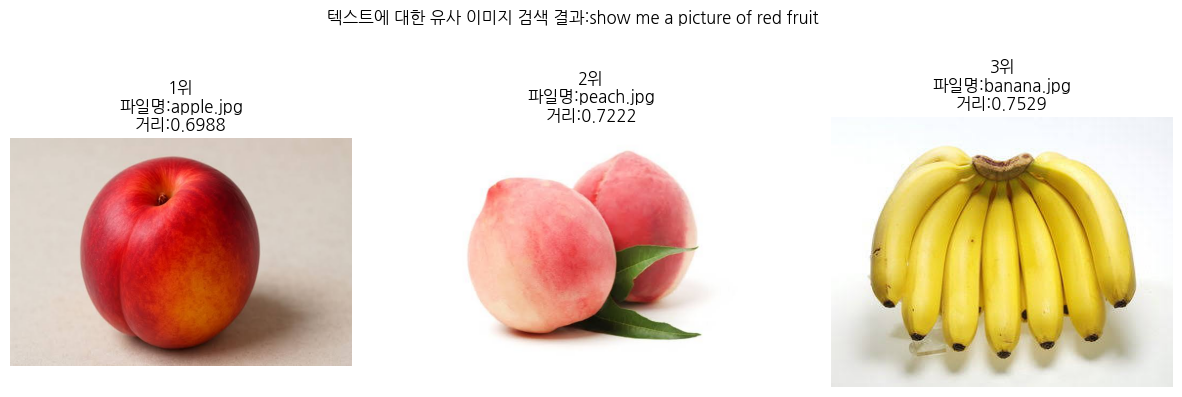

In [56]:
# 검색결과 이미지로 시각화
def show_resultes(query_title, results):
  count = len(results['documents'][0])
  print(f"count : {count}")

  fig, axes = plt.subplots(1, count, figsize=(5 * count, 5))
  if count == 1:
    axes = [axes]

  for i, (doc, meta, dist) in enumerate(
      zip(results['documents'][0],
          results['metadatas'][0],
          results['distances'][0])
  ):
    axes[i].imshow(Image.open(doc).convert("RGB"))
    axes[i].set_title(f"{i + 1}위\n파일명:{meta['filename']}\n거리:{dist:.4f}")
    axes[i].axis('off')
  plt.suptitle(query_title)
  plt.show()

# 이미지 검색 결과 시각화
if "image_results" in globals():
  show_resultes(f'유사 이미지 검색 결과:{query_image_path}',image_results)

# 텍스트 검색 결과 시각화
if "text_results" in globals():
  show_resultes(f'텍스트에 대한 유사 이미지 검색 결과:{query_text}',text_results)